In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
!pip install "numpy<1.24"


In [3]:
import tensorly as tl

tl.get_backend()

'cupy'

In [4]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]



Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied


In [5]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = labels

/tmp/ipykernel_595/3223033590.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = tl.tensor(epochs.get_data())


In [6]:
#%env PYTHONWARNINGS=error

In [7]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFwe
from hoda.classification import SelectF

clf = make_pipeline(
    SelectF(),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=4,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='oas',
        toeplitz=None,#(1,),
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
    ),
    #rank_grid=[1],
    verbose=True,
    extra_train_info=False,
    n_jobs=1,
    cv= StratifiedKFold(random_state=42,shuffle=True),
    truncate=True,
    clf=clf,
)
bttda.fit(X,y, test=True)

Model selection block 1/4...

Trying rank (1, 1)	score: 0.8004
Trying rank (2, 2)	score: 0.7896
Trying rank (4, 4)	score: 0.7619
Trying rank (8, 8)	score: 0.7962
Trying rank (8, 16)	score: 0.8252
Trying rank (8, 32)	score: 0.8230
Trying rank (8, 48)	score: 0.8161

Selected rank (8, 16) with score 0.8252
New ranks: [(8, 16)]


Model selection block 2/4...

Trying rank (1, 1)	score: 0.8288
Trying rank (2, 2)	score: 0.8281
Trying rank (4, 4)	score: 0.8260
Trying rank (8, 8)	score: 0.8282
Trying rank (8, 16)	score: 0.8290
Trying rank (8, 32)	score: 0.8205
Trying rank (8, 48)	score: 0.8188

Selected rank (8, 16) with score 0.8290
New ranks: [(8, 16), (8, 16)]


Model selection block 3/4...

Trying rank (1, 1)	score: 0.8302
Trying rank (2, 2)	score: 0.8292
Trying rank (4, 4)	score: 0.8285
Trying rank (8, 8)	score: 0.8286
Trying rank (8, 16)	score: 0.8291
Trying rank (8, 32)	score: 0.8246
Trying rank (8, 48)	score: 0.8225

Selected rank (1, 1) with score 0.8302
New ranks: [(8, 16), (8, 16), (

GreedyBTTDA(clf=Pipeline(steps=[('selectf', SelectF()),
                                ('functiontransformer',
                                 FunctionTransformer(func=<function CupyBackend.to_numpy at 0x7f561ffacdc0>)),
                                ('standardscaler', StandardScaler()),
                                ('lineardiscriminantanalysis',
                                 LinearDiscriminantAnalysis(shrinkage='auto',
                                                            solver='lsqr'))]),
            cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
            hoda_params={'delta': None, 'extra_train_info': False,
                         'init': 'random', 'max_iter': 128, 'obj': 'tr',
                         'random_state': 42, 'rank': (8, 8), 'shrinkage': 'oas',
                         'solver': 'lanczos', 'taper': False, 'toeplitz': None,
                         'tol': 1e-08, 'verbose': False},
            max_blocks=4, n_jobs=1, verbose=True)

In [15]:
bttda.model_select_info_

fold  train_score  val_score  n_features  test_score
block rank                                                         
0     (1, 1)      0     0.822836   0.811694           1    0.826469
      (1, 1)      1     0.832457   0.790368           1    0.817199
      (1, 1)      2     0.826339   0.818182           1    0.828415
      (1, 1)      3     0.836128   0.767522           1    0.819727
      (1, 1)      4     0.825214   0.814047           1    0.817831
...             ...          ...        ...         ...         ...
3     (8, 48)     0     0.909615   0.800148         641    0.849926
      (8, 48)     1     0.908811   0.854443         641    0.831375
      (8, 48)     2     0.908287   0.836730         641    0.839181
      (8, 48)     3     0.914207   0.796763         641    0.831897
      (8, 48)     4     0.907209   0.830038         641    0.838057

[140 rows x 5 columns]

In [16]:
bttda.model_select_info_best_

fold  train_score  val_score  n_features  test_score
block rank                                                         
0     (8, 16)     0     0.875160   0.808209         128    0.848291
      (8, 16)     1     0.875813   0.846461         128    0.839161
      (8, 16)     2     0.872156   0.849015         128    0.841569
      (8, 16)     3     0.880028   0.796062         128    0.830031
      (8, 16)     4     0.873116   0.826467         128    0.834375
1     (8, 16)     0     0.888212   0.818085         256    0.846545
      (8, 16)     1     0.886648   0.843426         256    0.838448
      (8, 16)     2     0.887607   0.849561         256    0.843585
      (8, 16)     3     0.891997   0.807446         256    0.828957
      (8, 16)     4     0.884872   0.826483         256    0.843104
2     (1, 1)      0     0.888622   0.816961         257    0.845773
      (1, 1)      1     0.887355   0.842061         257    0.839984
      (1, 1)      2     0.887188   0.850139         257    0.841248
      (1, 1)      3     0.892424   0.810077         257    0.827803
      (1, 1)      4     0.888313   0.831728         257    0.842020
3     (8, 8)      0     0.896585   0.817668         321    0.851772
      (8, 8)      1     0.893348   0.846108         321    0.846615
      (8, 8)      2     0.890292   0.852227         321    0.842422
      (8, 8)      3     0.897591   0.805788         321    0.828155
      (8, 8)      4     0.894577   0.835236         321    0.845411

In [17]:
bttda.model_select_info_best_.groupby(['block', 'rank'])['val_score'].aggregate('mean')

block  rank   
0      (8, 16)    0.825243
1      (8, 16)    0.829000
2      (1, 1)     0.830193
3      (8, 8)     0.831405
Name: val_score, dtype: float64

In [18]:
bttda.model_select_info_best_.groupby(['block', 'rank'])['test_score'].aggregate('mean')

block  rank   
0      (8, 16)    0.838685
1      (8, 16)    0.840128
2      (1, 1)     0.839366
3      (8, 8)     0.842875
Name: test_score, dtype: float64

block  rank  
0      (1, 1)    0.807051
1      (8, 8)    0.820216
2      (8, 8)    0.825298
3      (8, 8)    0.828784
4      (4, 4)    0.829647
5      (8, 8)    0.832404
6      (8, 8)    0.834165
7      (4, 4)    0.835178
Name: val_score, dtype: float64

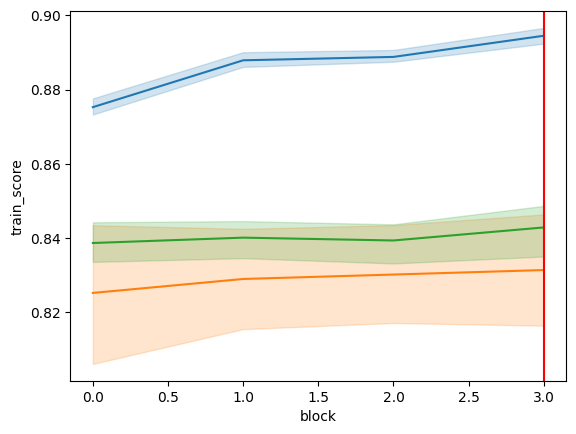

In [19]:
import seaborn as sns 
import matplotlib.pyplot as plt

plt.style.use('default')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='train_score')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='val_score')
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='test_score')
plt.axvline(bttda.n_blocks_-1, color='red')

<Axes: xlabel='block', ylabel='n_features'>

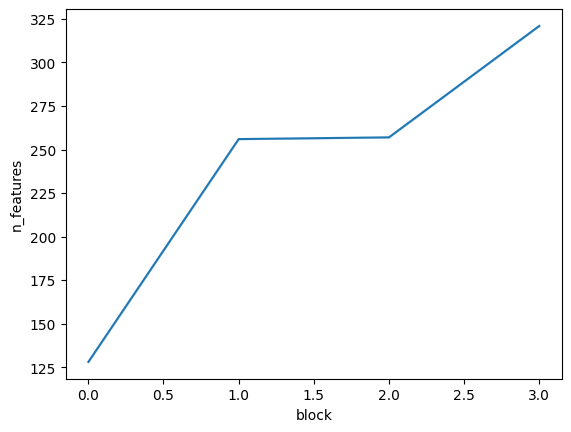

In [20]:
sns.lineplot(data=bttda.model_select_info_best_, x='block',y='n_features')


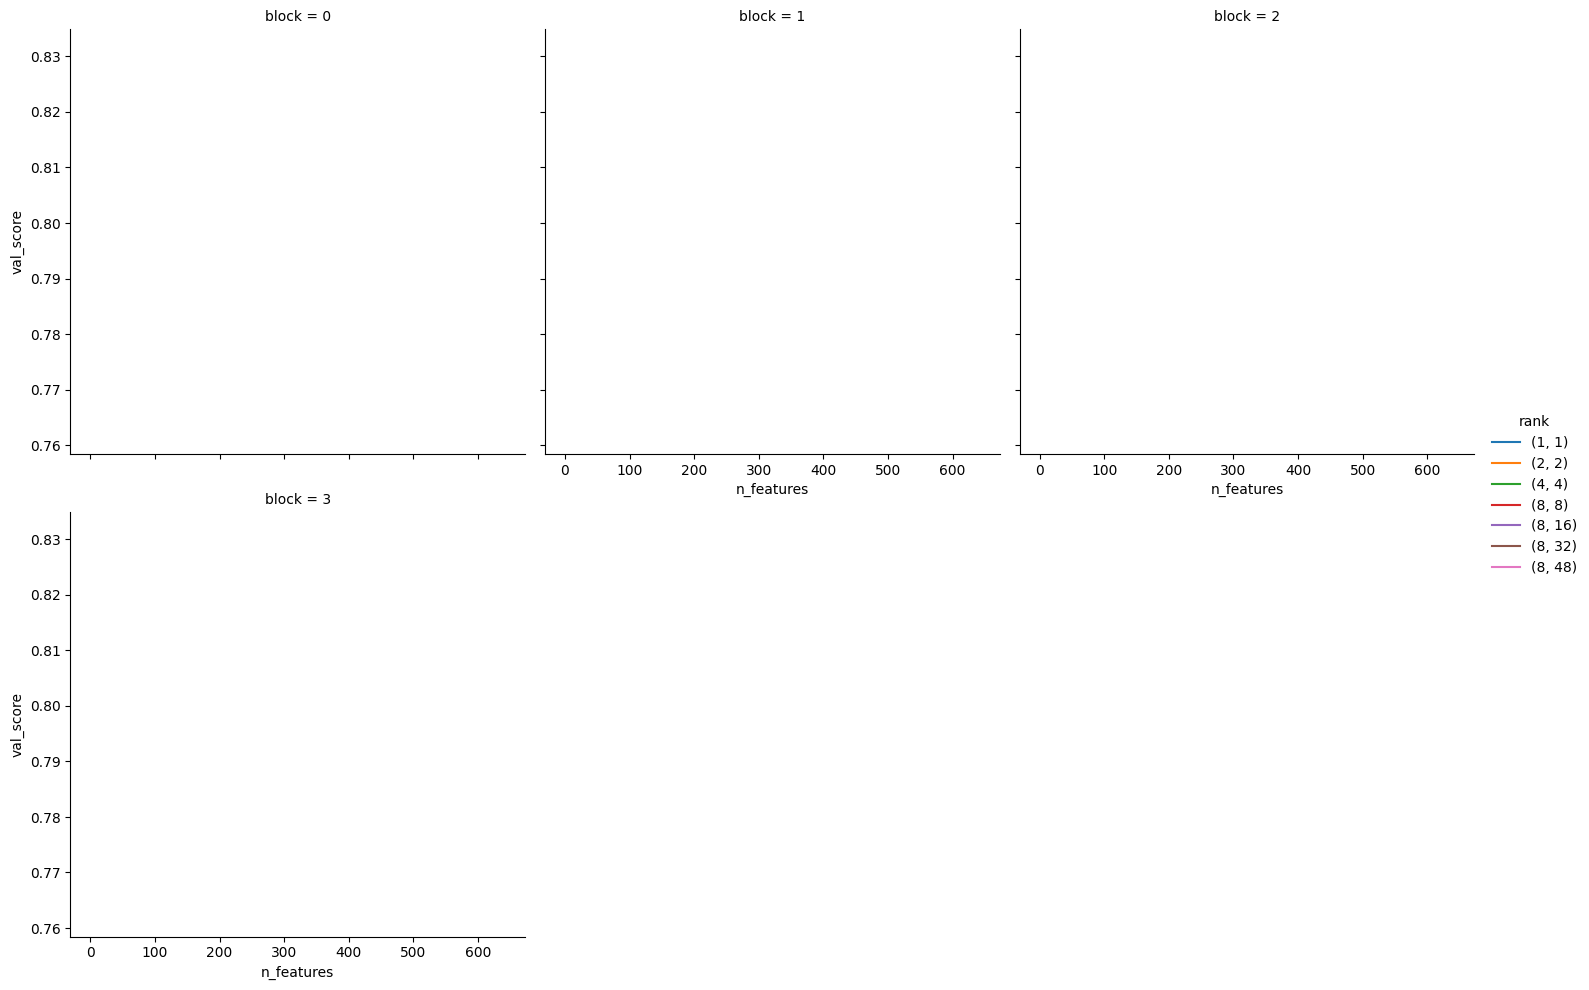

In [21]:
sns.relplot(
    data=bttda.model_select_info_.reset_index(),
    x='n_features',
    y='val_score',
    hue='rank',
    palette='tab10',
    col='block',
    kind='line',
    col_wrap=3,
    errorbar=None,
)
#plt.xscale('log')